# 02 — Proof of Concept : Modèle MMM sur un seul marché (France)

**Auteur :** Samir EL AISSAOUY  
**Objectif :** Entraîner et évaluer le modèle bayésien sur le marché FR

Pipeline :
1. Chargement et préparation des données FR
2. Feature engineering (adstock + saturation)
3. Entraînement BayesianMMM (mode OLS fallback si PyMC absent)
4. Prédictions et métriques
5. Contributions par canal
6. ROI par canal

---

## 1. Imports & Configuration

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from src.data.data_loader     import load_market_data, split_train_test
from src.data.feature_engineering import full_feature_pipeline
from src.models.bayesian_mmm  import BayesianMMM
from src.evaluation.metrics   import compute_all_metrics, print_metrics_report
from src.utils.visualization  import (
    plot_actual_vs_predicted,
    plot_channel_contributions,
    plot_roi_comparison,
    plot_saturation_curves,
)

MARKET = 'FR'
print(f'✅ Imports OK — Marché cible : {MARKET}')

✅ Imports OK — Marché cible : FR


## 2. Chargement des données

In [2]:
df = load_market_data(MARKET)
df_train, df_test = split_train_test(df, test_ratio=0.2)

print(f'Données totales : {len(df)} semaines')
print(f'Train : {len(df_train)} semaines ({df_train["date"].min().date()} → {df_train["date"].max().date()})')
print(f'Test  : {len(df_test)}  semaines ({df_test["date"].min().date()} → {df_test["date"].max().date()})')
df.head()

Données totales : 208 semaines
Train : 167 semaines (2020-01-06 → 2023-03-13)
Test  : 41  semaines (2023-03-20 → 2023-12-25)


,market,date,week,revenue,tv_spend,facebook_spend,search_spend,ooh_spend,print_spend,competitor_price,events,trend,seasonality,promotions
0,FR,2020-01-06,1,549916.39,20253.68,14048.77,8836.37,6995.42,5298.53,98.20,0.0,1.0004,0.7500,1.0
1,FR,2020-01-13,2,623187.41,34447.24,16309.48,14416.87,9491.60,6668.70,101.97,0.0,1.0008,0.7758,0.0
2,FR,2020-01-20,3,635235.82,25088.43,16680.11,8919.51,10110.19,4566.77,108.21,0.0,1.0011,0.8037,0.0
3,FR,2020-01-27,4,716027.45,33652.54,12407.94,16185.98,8113.74,8277.64,96.06,0.0,1.0015,0.8326,0.0
4,FR,2020-02-03,5,738705.30,23330.37,14739.44,16294.06,9837.53,6335.75,105.21,1.0,1.0019,0.8609,0.0


## 3. Feature Engineering

Features générées : 5 colonnes saturées
Config adstock    : ['tv', 'facebook', 'search', 'ooh', 'print']


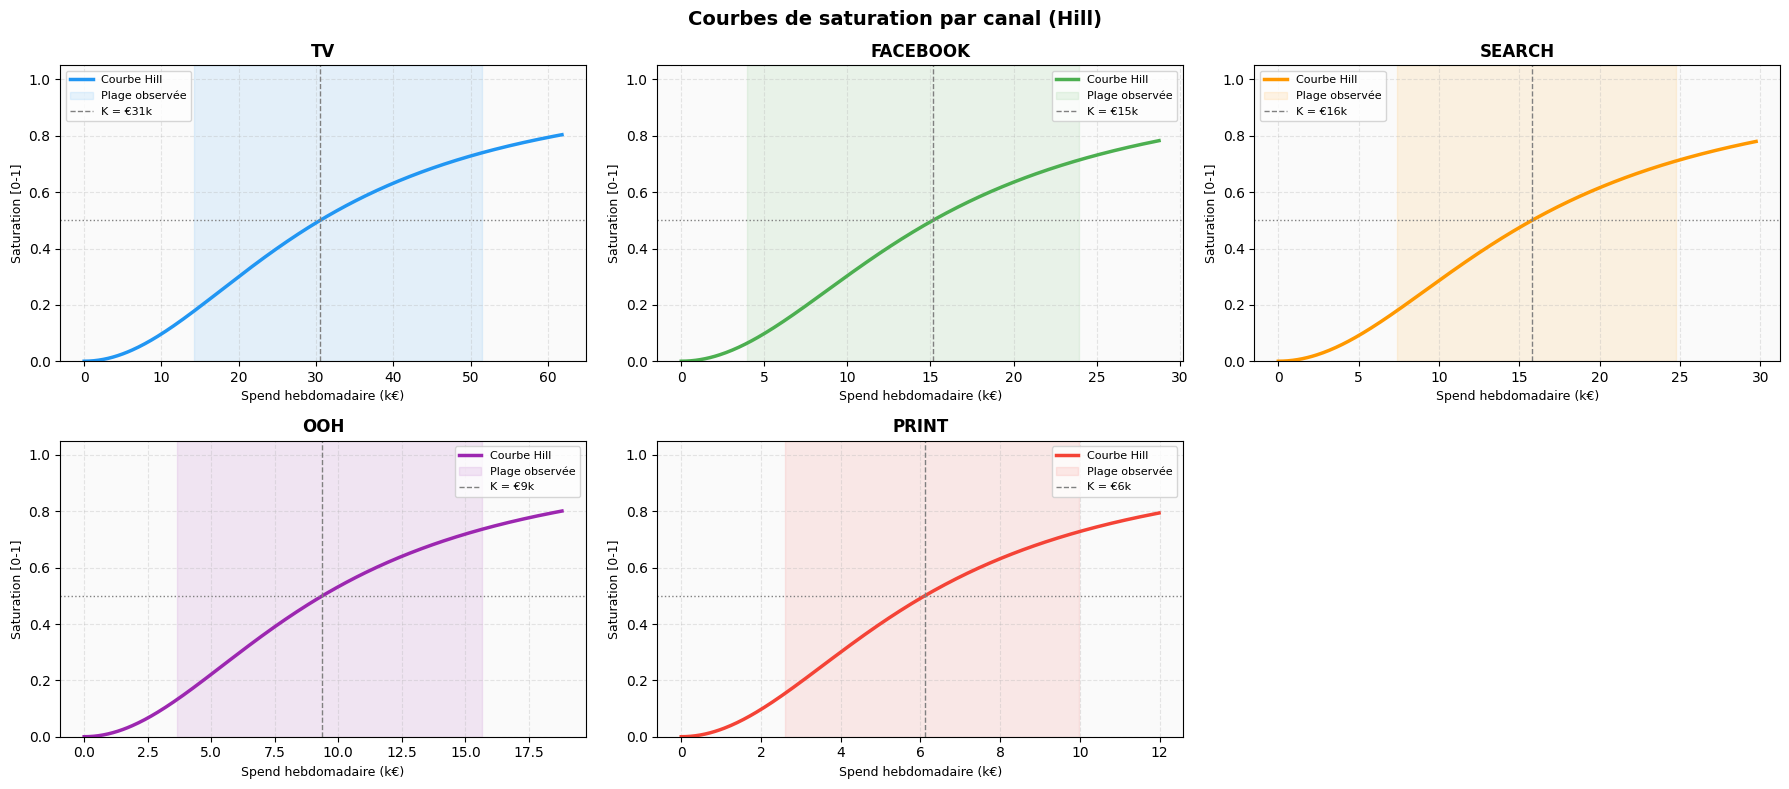

In [3]:
df_transformed, info = full_feature_pipeline(df_train, normalize=False)

print(f'Features générées : {info["n_features"]} colonnes saturées')
print(f'Config adstock    : {list(info["adstock_config"].keys())}')

# Visualisation des courbes de saturation
fig = plot_saturation_curves(df_train)
plt.show()

## 4. Entraînement du modèle

In [4]:
model = BayesianMMM(market=MARKET)

# Lance MCMC si PyMC disponible, sinon OLS fallback
model.fit(
    df_train,
    draws=1000,
    tune=1000,
    chains=4,
    random_seed=42,
)

print(f'\nModèle : {repr(model)}')

Initializing NUTS using jitter+adapt_diag...


🔧 Préparation des données — Marché : FR
⛓️  Sampling MCMC — 4 chains × 1000 draws + 1000 tune


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta_tv, beta_facebook, beta_search, beta_ooh, beta_print, gamma_seasonality, gamma_trend, gamma_events, base, sigma]


Output()

...

There were 80 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Sampling: [revenue_obs]


Output()

✅ Sampling terminé

──────────────────────────────────────────────────
  📊 Métriques — Train [FR]
──────────────────────────────────────────────────
  ✅  R²     : 0.9380   (objectif ≥ 0.85)
  ✅  MAPE   : 2.58%  (objectif ≤ 15%)
      sMAPE  : 2.58%
      RMSE   : €25,577
  ✅  NRMSE  : 0.0577  (objectif ≤ 0.15)
──────────────────────────────────────────────────


Modèle : BayesianMMM(market='FR', channels=['tv', 'facebook', 'search', 'ooh', 'print'], status=fitted)


## 5. Métriques de performance

In [5]:
# Sur le train
y_pred_train = model.predict(df_train)
metrics_train = compute_all_metrics(df_train['revenue'].values, y_pred_train)
print_metrics_report(metrics_train, label=f'Train [{MARKET}]')

# Sur le test
y_pred_test = model.predict(df_test)
metrics_test = compute_all_metrics(df_test['revenue'].values, y_pred_test)
print_metrics_report(metrics_test, label=f'Test [{MARKET}]')


──────────────────────────────────────────────────
  📊 Métriques — Train [FR]
──────────────────────────────────────────────────
  ✅  R²     : 0.9380   (objectif ≥ 0.85)
  ✅  MAPE   : 2.58%  (objectif ≤ 15%)
      sMAPE  : 2.58%
      RMSE   : €25,577
  ✅  NRMSE  : 0.0577  (objectif ≤ 0.15)
──────────────────────────────────────────────────


──────────────────────────────────────────────────
  📊 Métriques — Test [FR]
──────────────────────────────────────────────────
  ⚠️   R²     : 0.8249   (objectif ≥ 0.85)
  ✅  MAPE   : 4.94%  (objectif ≤ 15%)
      sMAPE  : 4.78%
      RMSE   : €47,628
  ✅  NRMSE  : 0.1271  (objectif ≤ 0.15)
──────────────────────────────────────────────────



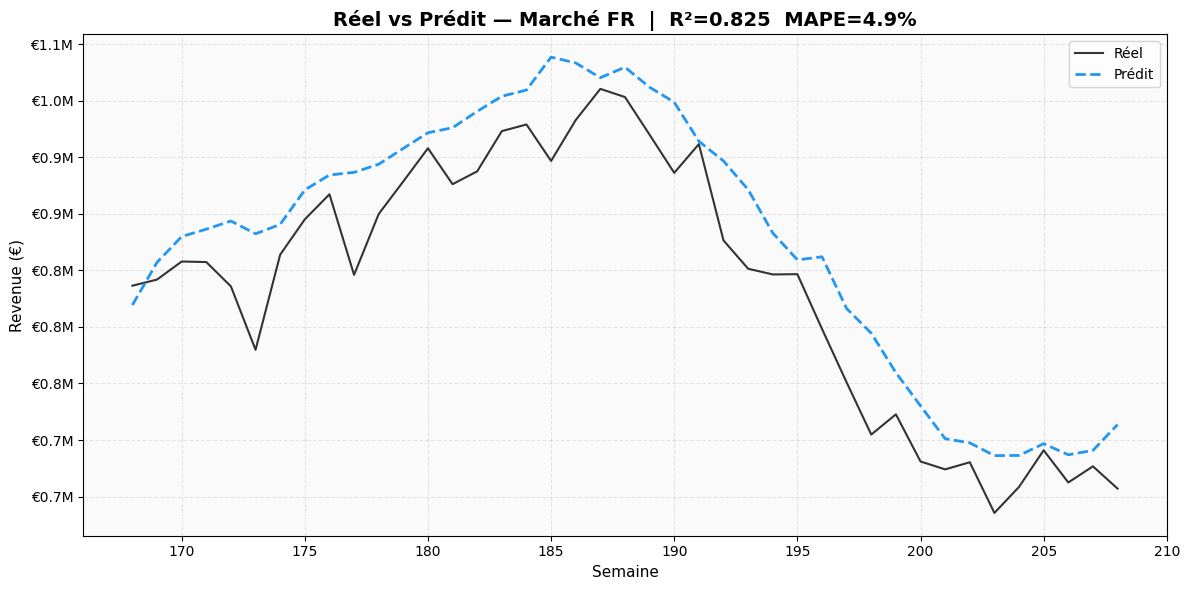

In [6]:
# Graphique réel vs prédit (test set)
fig = plot_actual_vs_predicted(df_test, y_pred_test, market=MARKET)
plt.show()

## 6. Décomposition des contributions

In [7]:
contributions = model.get_contributions(df_train)
print('Colonnes disponibles :', contributions.columns.tolist())
contributions.head()

Colonnes disponibles : ['date', 'market', 'week', 'revenue_actual', 'revenue_predicted', 'base', 'tv', 'facebook', 'search', 'ooh', 'print', 'seasonality_contrib', 'trend_contrib', 'events_contrib']


,date,market,week,revenue_actual,revenue_predicted,base,tv,facebook,search,ooh,print,seasonality_contrib,trend_contrib,events_contrib
0,2020-01-06,FR,1,549916.39,577176.808045,28072.702409,3868.036428,19330.460918,12705.459834,7699.187130,10915.771688,386314.785342,108270.404296,0.00000
1,2020-01-13,FR,2,623187.41,648164.705306,28072.702409,15938.539898,30797.489991,28744.047665,18778.085917,17916.130327,399604.013958,108313.695142,0.00000
2,2020-01-20,FR,3,635235.82,661053.034583,28072.702409,19110.064627,34241.565218,18542.909244,24345.166364,14419.539472,413974.923972,108346.163276,0.00000
3,2020-01-27,FR,4,716027.45,697134.563153,28072.702409,24854.161048,28756.990645,33056.395377,23395.334467,21748.604719,428860.920368,108389.454121,0.00000
4,2020-02-03,FR,5,738705.30,722618.267206,28072.702409,23588.213157,30786.614498,35098.044025,25754.881709,19674.730076,443437.864934,108432.744967,7772.47143


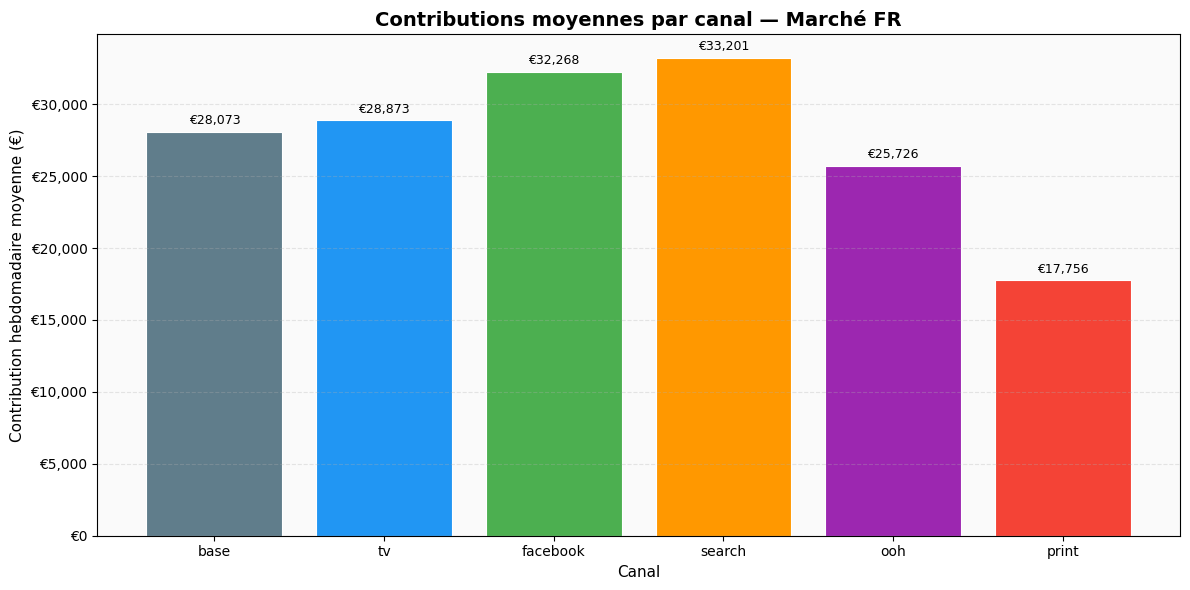


Contribution moyenne hebdomadaire :
  base         : €    28,073  (16.9%)
  tv           : €    28,873  (17.4%)
  facebook     : €    32,268  (19.5%)
  search       : €    33,201  (20.0%)
  ooh          : €    25,726  (15.5%)
  print        : €    17,756  (10.7%)


In [8]:
# Contributions moyennes par canal
fig = plot_channel_contributions(contributions, market=MARKET)
plt.show()

# Résumé chiffré
channels = ['base', 'tv', 'facebook', 'search', 'ooh', 'print']
contrib_summary = contributions[[c for c in channels if c in contributions.columns]].mean()
print('\nContribution moyenne hebdomadaire :')
for canal, val in contrib_summary.items():
    pct = val / contrib_summary.sum() * 100
    print(f'  {canal:12s} : €{val:>10,.0f}  ({pct:.1f}%)')

## 7. ROI par canal

 channel  total_spend_€  total_contribution_€    roi  roi_per_1k€
   print     1014877.96            2965176.78 2.9217      2921.71
     ooh     1561583.60            4296302.89 2.7512      2751.25
  search     2603569.68            5544625.21 2.1296      2129.62
facebook     2562069.74            5388695.54 2.1033      2103.26
      tv     5148171.59            4821745.27 0.9366       936.59


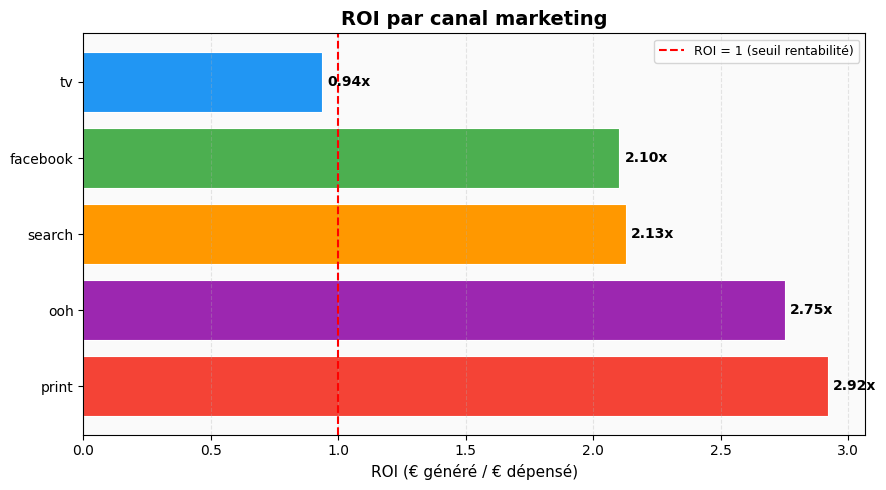

In [9]:
roi_df = model.get_roi(df_train)
print(roi_df.to_string(index=False))

fig = plot_roi_comparison(roi_df)
plt.show()

## 8. Résumé exécutif

In [10]:
roi_df = model.get_roi(df_train)
best_channel = roi_df.loc[roi_df["roi"].idxmax(), "channel"]

print(f'Marché         : FR')
print(f'Observations   : {len(df_train)}')
print(f'Meilleur canal : {best_channel}')
print(f'\nR²   train : {metrics_train["r2"]:.3f}')
print(f'MAPE train : {metrics_train["mape"]:.1f}%')
print(f'R²   test  : {metrics_test["r2"]:.3f}')
print(f'MAPE test  : {metrics_test["mape"]:.1f}%')

Marché         : FR
Observations   : 167
Meilleur canal : print

R²   train : 0.938
MAPE train : 2.6%
R²   test  : 0.825
MAPE test  : 4.9%
